<a href="https://colab.research.google.com/github/kailashchaudhary-p/Daily-Expense-Analyzer/blob/main/Daily_Expense_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
  df=pd.read_csv("/content/Transactions.csv")
  print(f"data set load succesfully . shape :{df.shape}")
except Exception as e:
  print(f"Error loading the data set : {e}")
df.head()


data set load succesfully . shape :(2461, 8)


,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


In [2]:
df.tail()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
2456,1/1/2015,Cash,Transportation,NaN,share jeep - Place T base to top,20.0,Expense,INR
2457,1/1/2015,Cash,Transportation,NaN,share auto - Place H to Place T base,20.0,Expense,INR
2458,1/1/2015,Cash,Transportation,NaN,bus - brc to Place H,30.0,Expense,INR
2459,1/1/2015,Cash,Food,NaN,tea,10.0,Expense,INR
2460,1/1/2015,Cash,Transportation,NaN,share auto - hospital to brc station,10.0,Expense,INR


In [3]:
df.columns

Index(['Date', 'Mode', 'Category', 'Subcategory', 'Note', 'Amount',
       'Income/Expense', 'Currency'],
      dtype='object')

In [4]:
df.isnull().sum()

,0
Date,0
Mode,0
Category,0
Subcategory,635
Note,521
Amount,0
Income/Expense,0
Currency,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   object 
 1   Mode            2461 non-null   object 
 2   Category        2461 non-null   object 
 3   Subcategory     1826 non-null   object 
 4   Note            1940 non-null   object 
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   object 
 7   Currency        2461 non-null   object 
dtypes: float64(1), object(7)
memory usage: 153.9+ KB


In [6]:
df["Mode"].unique()

array(['Cash', 'Saving Bank account 1', 'Credit Card',
       'Equity Mutual Fund B', 'Debit Card', 'Share Market Trading',
       'Saving Bank account 2', 'Equity Mutual Fund C',
       'Equity Mutual Fund A', 'Equity Mutual Fund D', 'Fixed Deposit',
       'Recurring Deposit'], dtype=object)

In [7]:
df['Category'].unique()

array(['Transportation', 'Food', 'subscription', 'Festivals', 'Other',
       'Small Cap fund 2', 'Small cap fund 1', 'Family',
       'Equity Mutual Fund E', 'Apparel', 'Public Provident Fund',
       'Saving Bank account 1', 'Gift', 'Salary', 'Household',
       'Dividend earned on Shares', 'Interest', 'Life Insurance',
       'Beauty', 'Health', 'Money transfer', 'maid', 'Culture',
       'Tax refund', 'Tourism', 'Share Market', 'Self-development',
       'Amazon pay cashback', 'Education', 'scrap', 'Petty cash',
       'Documents', 'Gpay Reward', 'Social Life', 'Equity Mutual Fund A',
       'Maturity amount', 'Fixed Deposit', 'Equity Mutual Fund C',
       'Equity Mutual Fund F', 'Recurring Deposit',
       'Saving Bank account 2', 'Equity Mutual Fund D',
       'Equity Mutual Fund B', 'Bonus', 'Investment', 'Grooming', 'Rent',
       'Cook', 'garbage disposal', 'water (jar /tanker)'], dtype=object)

In [8]:
df['Income/Expense'].unique()

array(['Expense', 'Transfer-Out', 'Income'], dtype=object)

In [9]:
df.duplicated().sum()

np.int64(9)

In [10]:
expense_df = df[df['Income/Expense']=='Expense']

In [11]:
expense_df.shape

(2176, 8)

In [12]:
expense_df.head(10)

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR
5,15/09/2018 06:34:17,Credit Card,subscription,Tata Sky,Permanent Residence - Tata Play recharge,200.0,Expense,INR
6,14/09/2018 05:39:17,Cash,Transportation,auto,Place 2 station to Permanent Residence,50.0,Expense,INR
7,13/09/2018 21:35:15,Saving Bank account 1,Transportation,Train,2 Place 0 to Place 3,40.0,Expense,INR
8,13/09/2018 21:01:47,Credit Card,Other,NaN,HBR 2 Months subscription,83.0,Expense,INR
9,13/09/2018 21:01:32,Cash,Food,Grocery,1kg atta,46.0,Expense,INR


In [13]:
len(expense_df)

2176

In [14]:
expense_df['Category'].value_counts()

,count
Category,
Food,907
Transportation,307
Household,176
subscription,143
Other,114
Investment,103
Health,94
Family,71
Apparel,47


In [15]:
expense_df['Mode'].value_counts()

,count
Mode,
Cash,1039
Saving Bank account 1,971
Credit Card,162
Debit Card,2
Saving Bank account 2,2


In [16]:
expense_df.isnull().sum()

,0
Date,0
Mode,0
Category,0
Subcategory,350
Note,346
Amount,0
Income/Expense,0
Currency,0


In [17]:
expense_df [expense_df['Category'] == 'Investment'].head(10)

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
1751,10/12/2016,Saving Bank account 1,Investment,Mutual fund,NaN,1000.0,Expense,INR
1756,7/12/2016,Saving Bank account 1,Investment,Mutual fund,NaN,1000.0,Expense,INR
1758,5/12/2016,Saving Bank account 1,Investment,Mutual fund,NaN,1000.0,Expense,INR
1772,1/12/2016,Saving Bank account 1,Investment,Public Provident Fund,NaN,40000.0,Expense,INR
1813,10/11/2016,Saving Bank account 1,Investment,RD,RD,1000.0,Expense,INR
1814,10/11/2016,Saving Bank account 1,Investment,LIC,Life Insurance,11286.0,Expense,INR
1815,10/11/2016,Saving Bank account 1,Investment,Mutual fund,NaN,1000.0,Expense,INR
1816,10/11/2016,Saving Bank account 1,Investment,Mutual fund,NaN,1000.0,Expense,INR
1821,5/11/2016,Saving Bank account 1,Investment,RD,RD,1000.0,Expense,INR
1822,5/11/2016,Saving Bank account 1,Investment,Mutual fund,NaN,1000.0,Expense,INR


In [18]:
expense_df.isnull().sum()

,0
Date,0
Mode,0
Category,0
Subcategory,350
Note,346
Amount,0
Income/Expense,0
Currency,0


In [19]:
expense_df['Subcategory'] = expense_df['Subcategory'].fillna('Unknown')

/tmp/ipykernel_916/1614961070.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  expense_df['Subcategory'] = expense_df['Subcategory'].fillna('Unknown')


In [20]:
expense_df['Note'] = expense_df['Note'].fillna('No Note')

/tmp/ipykernel_916/425735231.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  expense_df['Note'] = expense_df['Note'].fillna('No Note')


In [21]:
expense_df.head(10)

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR
5,15/09/2018 06:34:17,Credit Card,subscription,Tata Sky,Permanent Residence - Tata Play recharge,200.0,Expense,INR
6,14/09/2018 05:39:17,Cash,Transportation,auto,Place 2 station to Permanent Residence,50.0,Expense,INR
7,13/09/2018 21:35:15,Saving Bank account 1,Transportation,Train,2 Place 0 to Place 3,40.0,Expense,INR
8,13/09/2018 21:01:47,Credit Card,Other,Unknown,HBR 2 Months subscription,83.0,Expense,INR
9,13/09/2018 21:01:32,Cash,Food,Grocery,1kg atta,46.0,Expense,INR


In [22]:
expense_df.isnull().sum()

,0
Date,0
Mode,0
Category,0
Subcategory,0
Note,0
Amount,0
Income/Expense,0
Currency,0


In [23]:
expense_df.duplicated().sum()

np.int64(3)

In [24]:
expense_df[expense_df.duplicated(keep=False)]

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
1360,12/5/2017,Cash,Food,Tea,No Note,10.0,Expense,INR
1362,12/5/2017,Cash,Food,Tea,No Note,10.0,Expense,INR
1815,10/11/2016,Saving Bank account 1,Investment,Mutual fund,No Note,1000.0,Expense,INR
1816,10/11/2016,Saving Bank account 1,Investment,Mutual fund,No Note,1000.0,Expense,INR
1853,10/10/2016,Saving Bank account 1,Investment,Mutual fund,No Note,1000.0,Expense,INR
1854,10/10/2016,Saving Bank account 1,Investment,Mutual fund,No Note,1000.0,Expense,INR


In [25]:
expense_df.shape

(2176, 8)

In [26]:
expense_df.duplicated().sum()

np.int64(3)

In [27]:
expense_df=expense_df.drop_duplicates()

In [28]:
expense_df.duplicated().sum()

np.int64(0)

In [29]:
expense_df['Date'].dtype

dtype('O')

In [30]:
expense_df['Date']=pd.to_datetime(expense_df['Date'],dayfirst=True,format='mixed')

In [31]:
expense_df['Date'].dtype

dtype('<M8[ns]')

In [32]:
expense_df['Date'].head(10)



,Date
0,2018-09-20 12:04:08
1,2018-09-20 12:03:15
2,2018-09-19 00:00:00
3,2018-09-17 23:41:17
4,2018-09-16 17:15:08
5,2018-09-15 06:34:17
6,2018-09-14 05:39:17
7,2018-09-13 21:35:15
8,2018-09-13 21:01:47
9,2018-09-13 21:01:32


In [33]:
expense_df["Amount"].dtype

dtype('float64')

In [34]:
expense_df["Amount"].describe()


,Amount
count,2173.000000
mean,899.852982
std,3840.590420
min,2.000000
25%,30.000000
50%,83.000000
75%,371.000000
max,100000.000000


In [35]:
expense_df[expense_df["Amount"] == 100000]

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
1710,2017-01-01,Saving Bank account 1,Money transfer,Unknown,No Note,100000.0,Expense,INR


In [36]:
expense_df[expense_df['Amount']=='Money transfer'][['Date','Mode','Subcategory','Note','Amount']]

,Date,Mode,Subcategory,Note,Amount


In [37]:
expense_df['Category'].value_counts().loc['Money transfer']

np.int64(43)

In [38]:
expense_df[expense_df['Category']=='Money transfer']['Amount'].sum()

np.float64(606528.9)

In [39]:
expense_df[expense_df['Category']=='Money transfer']['Amount'].describe()

,Amount
count,43.000000
mean,14105.323256
std,15583.173438
min,23.000000
25%,10000.000000
50%,10000.000000
75%,10000.000000
max,100000.000000


In [40]:
expense_df[expense_df['Amount'] <=0]

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency


In [41]:
expense_df['Category'].unique()

array(['Transportation', 'Food', 'subscription', 'Festivals', 'Other',
       'Family', 'Apparel', 'Gift', 'Household', 'Beauty', 'Health',
       'Money transfer', 'maid', 'Culture', 'Tourism', 'Self-development',
       'Education', 'Documents', 'Social Life', 'Investment',
       'Recurring Deposit', 'Grooming', 'Public Provident Fund', 'Rent',
       'Cook', 'garbage disposal', 'water (jar /tanker)'], dtype=object)

In [42]:
expense_df["Category"].value_counts().loc["subscription"]

np.int64(143)

In [43]:
expense_df['Category'] = expense_df['Category'].replace('subscription','Subscription')

In [44]:
expense_df.isnull().sum()

,0
Date,0
Mode,0
Category,0
Subcategory,0
Note,0
Amount,0
Income/Expense,0
Currency,0


In [45]:
expense_df.shape

(2173, 8)

In [46]:
expense_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2173 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            2173 non-null   datetime64[ns]
 1   Mode            2173 non-null   object        
 2   Category        2173 non-null   object        
 3   Subcategory     2173 non-null   object        
 4   Note            2173 non-null   object        
 5   Amount          2173 non-null   float64       
 6   Income/Expense  2173 non-null   object        
 7   Currency        2173 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 152.8+ KB


In [47]:
expense_df['Amount'].sum()

np.float64(1955380.5300000003)

In [48]:
expense_df['Amount'].describe()

,Amount
count,2173.000000
mean,899.852982
std,3840.590420
min,2.000000
25%,30.000000
50%,83.000000
75%,371.000000
max,100000.000000


In [49]:
expense_df.groupby('Category').value_counts()

Category             Date                 Mode  Subcategory  Note           Amount  Income/Expense  Currency
Apparel              2015-02-01 00:00:00  Cash  Unknown      undergarments  248.0   Expense         INR         1
                     2015-02-23 18:39:59  Cash  Footwear     shoe polish    20.0    Expense         INR         1
                     2015-03-14 19:21:18  Cash  Laundry      ironing        40.0    Expense         INR         1
                     2015-03-15 18:39:12  Cash  Clothing     altering       30.0    Expense         INR         1
                     2015-03-20 21:36:58  Cash  Laundry      dry cleaning   100.0   Expense         INR         1
                                                                                                               ..
maid                 2018-07-03 00:00:00  Cash  Unknown      No Note        500.0   Expense         INR         1
                     2018-07-31 13:45:08  Cash  Unknown      July salary    2000.0  Expense         INR         1
water (jar /tanker)  2015-03-03 00:00:00  Cash  Unknown      water jar      108.0   Expense         INR         1
                     2015-03-23 13:17:56  Cash  Unknown      refilling      20.0    Expense         INR         1
                     2015-03-25 14:02:02  Cash  Unknown      No Note        20.0    Expense         INR         1
Name: count, Length: 2173, dtype: int64

In [50]:
expense_df['Category'].value_counts()

,count
Category,
Food,906
Transportation,307
Household,176
Subscription,143
Other,114
Investment,101
Health,94
Family,71
Apparel,47


In [51]:
expense_df.groupby('Mode')['Amount'].sum().sort_values(ascending=False)

,Amount
Mode,
Saving Bank account 1,1575728.46
Credit Card,205254.01
Cash,173421.00
Debit Card,942.36
Saving Bank account 2,34.70


In [52]:
expense_df['Day_Type']=expense_df['Date'].dt.day_of_week.apply(lambda x: 'Weekend' if x >5 else 'Weekday')

In [53]:
expense_df.groupby('Day_Type')['Amount'].sum()

,Amount
Day_Type,
Weekday,1589501.81
Weekend,365878.72


In [54]:
category_spending=expense_df.groupby('Category')['Amount'].sum()
category_spending

,Amount
Category,
Apparel,25373.82
Beauty,4189.00
Cook,12443.00
Culture,4304.36
Documents,100.00
Education,537.00
Family,78582.20
Festivals,6911.00
Food,96393.10


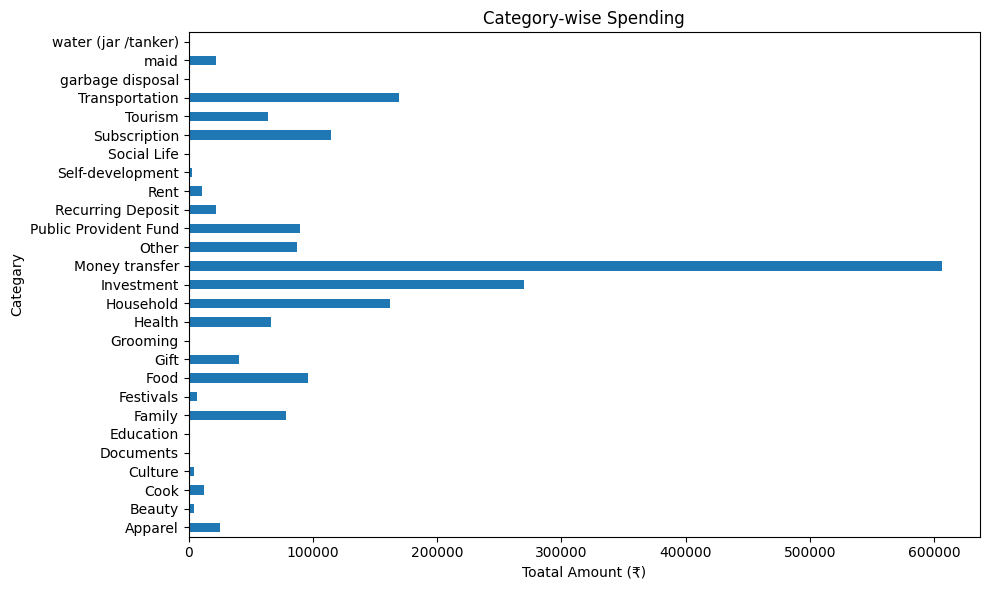

In [55]:
category_spending.plot(kind="barh" , figsize=(10,6))

plt.title("Category-wise Spending")
plt.xlabel("Toatal Amount (₹)")
plt.ylabel("Categary")
plt.tight_layout()
plt.show()

In [56]:
monthly_spending=expense_df.groupby(expense_df['Date'].dt.to_period('M'))['Amount'].sum()
monthly_spending

,Amount
Date,
2015-01,33870.00
2015-02,24308.00
2015-03,32631.40
2015-04,24222.00
2015-05,63118.00
2015-06,19567.00
2015-07,31735.00
2015-08,43340.00
2015-09,18577.00


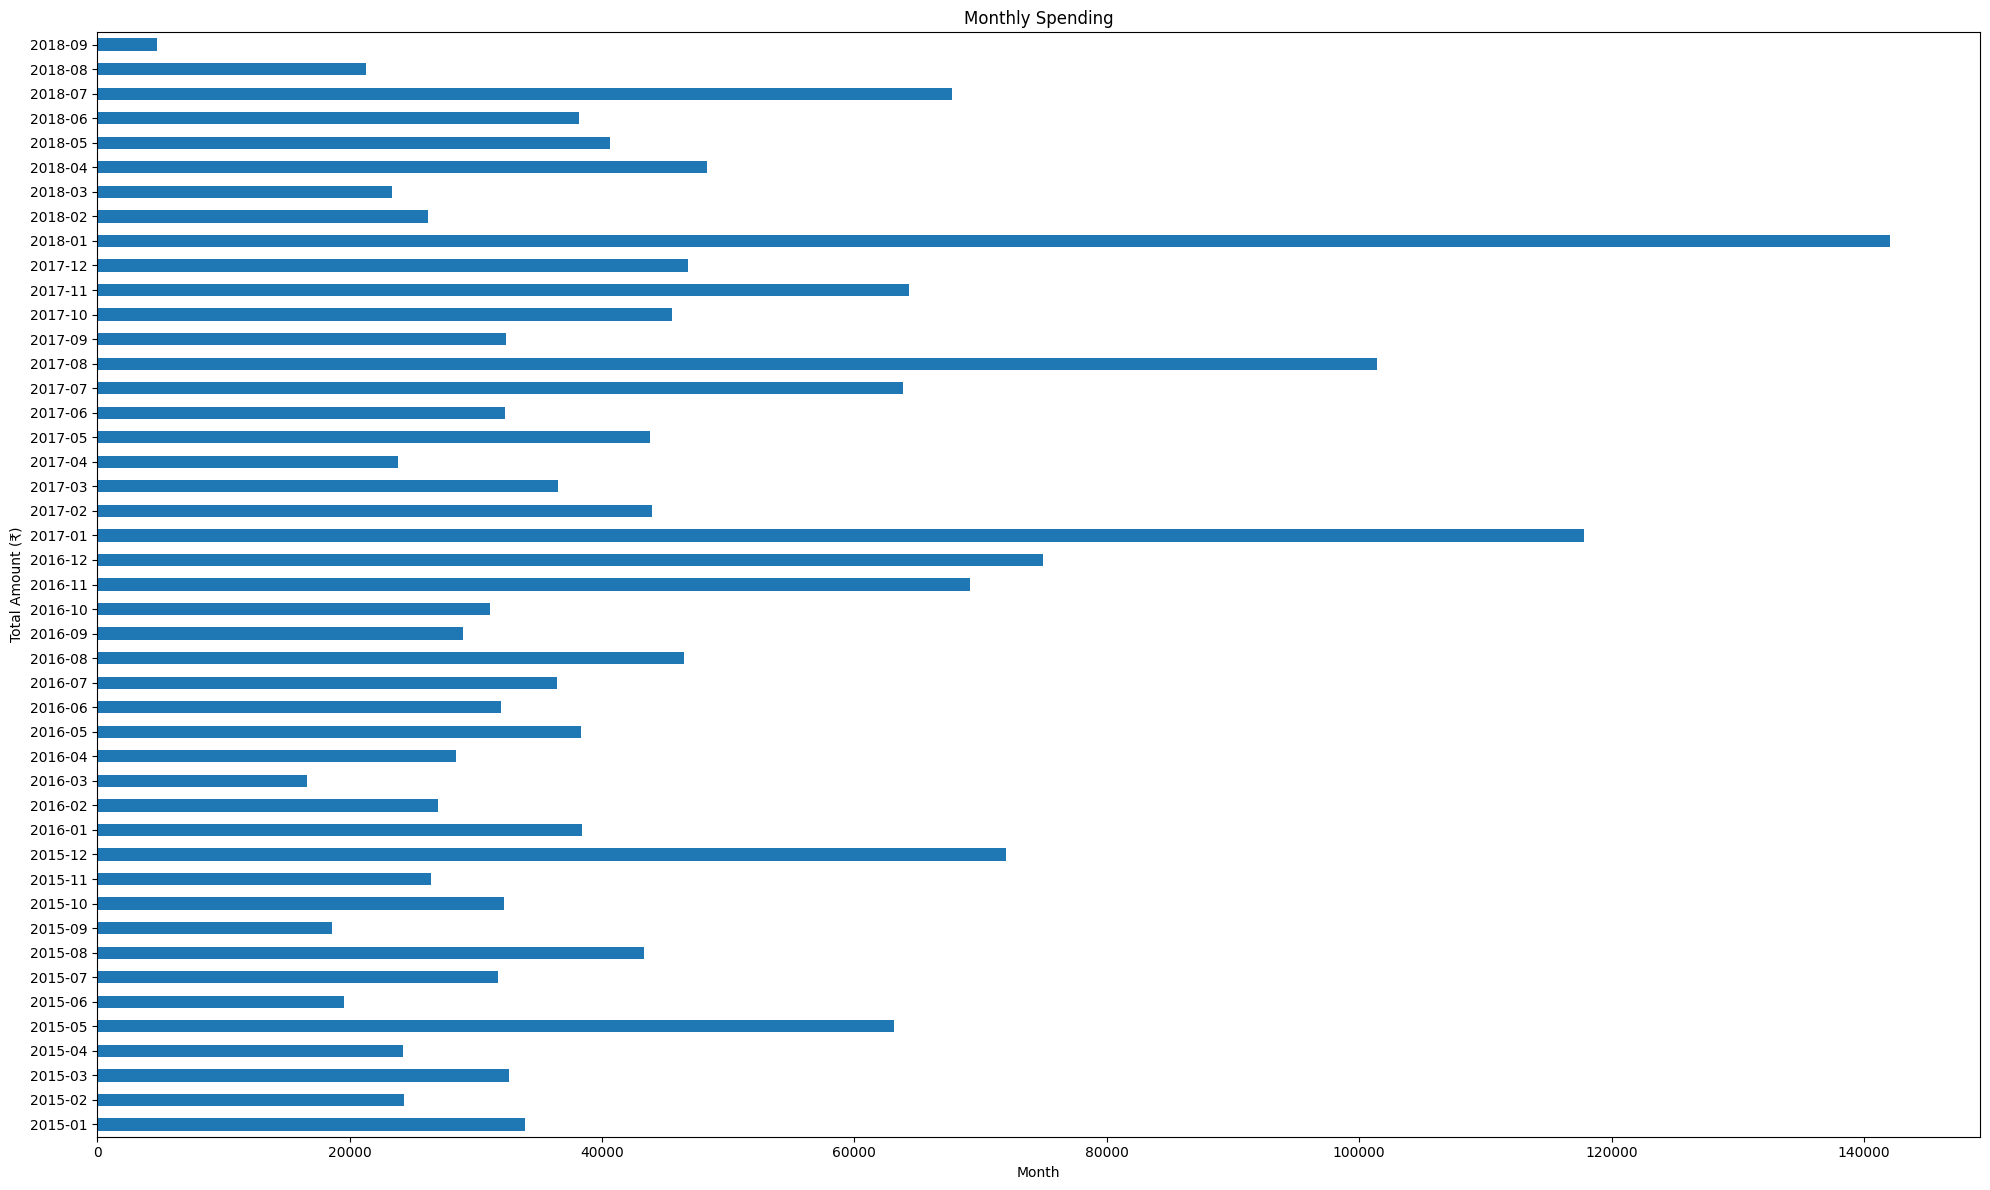

In [57]:
monthly_spending.plot(kind="barh",figsize=(20,12))
plt.title("Monthly Spending")
plt.xlabel('Month')
plt.ylabel('Total Amount (₹)')
plt.tight_layout()
plt.show()

In [58]:
payment_spending=expense_df.groupby("Mode")['Amount'].sum()
payment_spending

,Amount
Mode,
Cash,173421.00
Credit Card,205254.01
Debit Card,942.36
Saving Bank account 1,1575728.46
Saving Bank account 2,34.70


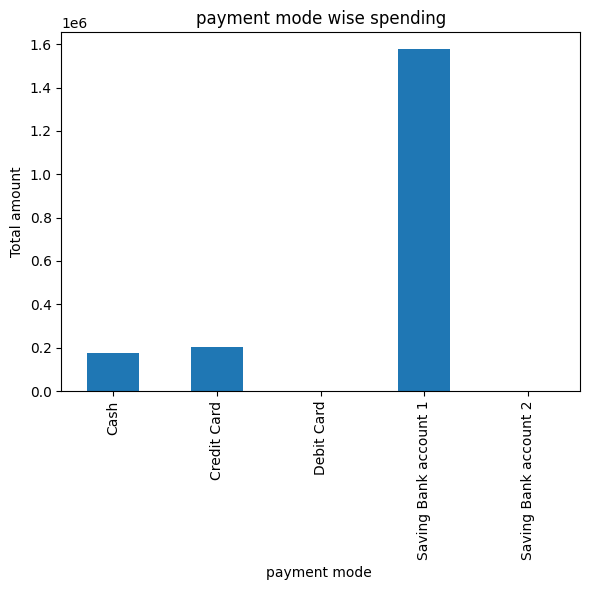

In [59]:
payment_spending.plot(kind="bar",figsize=(6,6))
plt.title('payment mode wise spending')
plt.xlabel('payment mode ')
plt.ylabel('Total amount')
plt.tight_layout()
plt.show()

In [60]:
day_type_spending=expense_df.groupby('Day_Type')['Amount'].sum()
day_type_spending

,Amount
Day_Type,
Weekday,1589501.81
Weekend,365878.72


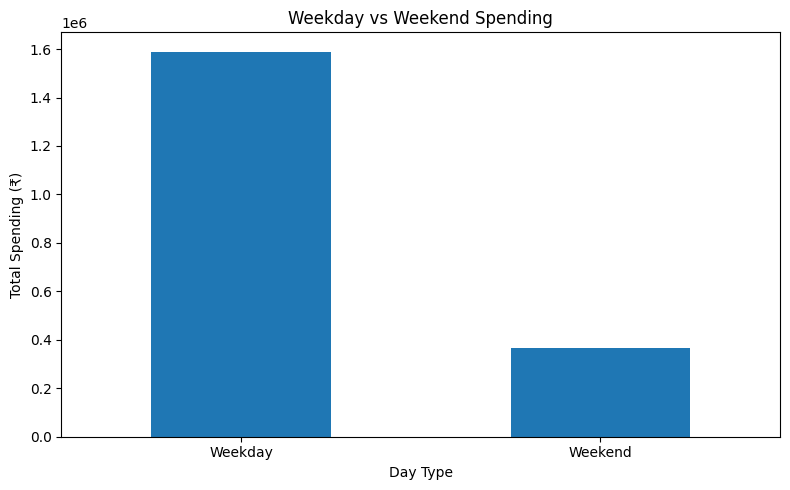

In [61]:
day_type_spending.plot(kind="bar", figsize=(8,5))

plt.title("Weekday vs Weekend Spending")
plt.xlabel("Day Type")
plt.ylabel("Total Spending (₹)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [62]:
expense_df['Year']=expense_df['Date'].dt.year

In [63]:
expense_df[['Year','Date']].head()

,Year,Date
0,2018,2018-09-20 12:04:08
1,2018,2018-09-20 12:03:15
2,2018,2018-09-19 00:00:00
3,2018,2018-09-17 23:41:17
4,2018,2018-09-16 17:15:08


In [66]:
expense_df['Month']= expense_df["Date"].dt.month

In [67]:
expense_df[["Date", "Year", "Month"]].head()

,Date,Year,Month
0,2018-09-20 12:04:08,2018,9
1,2018-09-20 12:03:15,2018,9
2,2018-09-19 00:00:00,2018,9
3,2018-09-17 23:41:17,2018,9
4,2018-09-16 17:15:08,2018,9


In [68]:
expense_df['Day']=expense_df['Date'].dt.day

In [69]:
expense_df[['Date','Year','Month','Day']].head()

,Date,Year,Month,Day
0,2018-09-20 12:04:08,2018,9,20
1,2018-09-20 12:03:15,2018,9,20
2,2018-09-19 00:00:00,2018,9,19
3,2018-09-17 23:41:17,2018,9,17
4,2018-09-16 17:15:08,2018,9,16


In [70]:
expense_df['Week']=expense_df['Date'].dt.day_of_week

In [71]:
expense_df[['Date','Year','Month','Day','Week']].head()

,Date,Year,Month,Day,Week
0,2018-09-20 12:04:08,2018,9,20,3
1,2018-09-20 12:03:15,2018,9,20,3
2,2018-09-19 00:00:00,2018,9,19,2
3,2018-09-17 23:41:17,2018,9,17,0
4,2018-09-16 17:15:08,2018,9,16,6


In [72]:
expense_df['Day_Type']=expense_df['Date'].dt.day_name()

In [74]:
expense_df[['Date','Year','Month','Day','Week','Day_Type']].head()

,Date,Year,Month,Day,Week,Day_Type
0,2018-09-20 12:04:08,2018,9,20,3,Thursday
1,2018-09-20 12:03:15,2018,9,20,3,Thursday
2,2018-09-19 00:00:00,2018,9,19,2,Wednesday
3,2018-09-17 23:41:17,2018,9,17,0,Monday
4,2018-09-16 17:15:08,2018,9,16,6,Sunday
